In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from keras.datasets import cifar10
from sklearn.decomposition import PCA as CPU_PCA
from sklearn.metrics.pairwise import linear_kernel, rbf_kernel
import cuml
from cuml.svm import SVC as GPU_SVC
from cuml.model_selection import GridSearchCV as GPU_GridSearchCV
import seaborn as sns
import math

In [26]:
#Data Preprocessing
#Data Loading
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

x_train_full = x_train_full.reshape(x_train_full.shape[0], -1)
x_test_full = x_test_full.reshape(x_test_full.shape[0], -1)
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

train_df = pd.DataFrame(x_train_full)
train_df['label'] = y_train_full

ids_animals = [2, 3, 4, 5, 6, 7] # 30.000
ids_vehicles = [0, 1, 8, 9]      # 20.000

#Data relabelling
x_train = train_df.drop(columns=['label']).values
y_train = np.where(train_df['label'].isin(ids_vehicles), 1, -1)
y_test = np.where(np.isin(y_test_full, ids_vehicles), 1, -1)

print(f"Training Samples: {x_train.shape[0]}")
print(f"Animals (-1): {np.sum(y_train==-1)}")
print(f"Vehicles (1): {np.sum(y_train==1)}")


Training Samples: 50000
Animals (-1): 30000
Vehicles (1): 20000


In [ ]:
#Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype(np.float32))
x_test_scaled = scaler.transform(x_test_full.astype(np.float32))


In [27]:
# Grid Search Results Visualization: Accuracy & Hyperparameters-Training Time Comparison
def plot_grid_search_results(results, batch_size=8, title_prefix="Grid Search Results"):

    if hasattr(results, 'cv_results_'):
        df = pd.DataFrame(results.cv_results_)
    elif isinstance(results, list):
        df = pd.DataFrame(results)
    else:
        df = results.copy()

    # Label Creation
    def create_label(row):
        # Params
        if 'params' in row and isinstance(row['params'], dict):
            params_text = '\n'.join([f"{k}={v}" for k, v in row['params'].items()])
        else:
            params_text = str(row.name)
        # Time
        if 'mean_fit_time' in row:
            time_text = f"\nTime={row['mean_fit_time']:.2f}s"
        else:
            time_text = ""
        return params_text + time_text

    df['label'] = df.apply(create_label, axis=1)
    df = df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

    total_items = len(df)
    num_plots = math.ceil(total_items / batch_size)

    for i in range(num_plots):
        start = i * batch_size
        end = min((i + 1) * batch_size, total_items)
        subset = df.iloc[start:end].copy()

        plot_data = subset.melt(id_vars=['label'],
                                value_vars=['mean_train_score', 'mean_test_score'],
                                var_name='Metric', value_name='Accuracy')

        plt.figure(figsize=(14, 8))

        ax = sns.barplot(data=plot_data, x='label', y='Accuracy', hue='Metric',
                         palette=['#b0bec5', '#1e88e5'])

        plt.title(f"{title_prefix}: Rank {start+1}-{end}", fontsize=16, fontweight='bold')
        plt.ylabel("Accuracy", fontsize=12)
        plt.xlabel("")
        plt.legend(loc='upper right')

        min_score = plot_data['Accuracy'].min()
        max_score = plot_data['Accuracy'].max()

        spread = max_score - min_score

        padding_top = max(0.015, spread * 0.20)
        padding_bottom = max(0.01, spread * 0.10)

        plt.ylim(min_score - padding_bottom, max_score + padding_top)

        for container in ax.containers:
            ax.bar_label(container, fmt='%.4f', padding=2, fontweight='bold', fontsize=11)

        plt.tight_layout()
        plt.show()

In [28]:
# Hyperparameter Sensitivity Analysis: Mean Impact on Train/Validation Accuracy
def plot_parameter_impact_mean(results):

    if hasattr(results, 'cv_results_'):
        df = pd.DataFrame(results.cv_results_)
    else:
        df = results.copy()

    param_cols = [col for col in df.columns if col.startswith('param_')]

    for param in param_cols:
        param_name = param.replace('param_', '')

        plot_df = df[[param, 'mean_test_score', 'mean_train_score']].copy()

        plot_df[param] = pd.to_numeric(plot_df[param], errors='coerce')
        plot_df = plot_df.dropna(subset=[param])

        plot_df = (
            plot_df
            .groupby(param, as_index=False)
            .mean()
            .sort_values(param)
        )

        x = plot_df[param].values
        val = plot_df['mean_test_score'].values
        train = plot_df['mean_train_score'].values

        plt.figure(figsize=(9, 5))

        plt.plot(x, val, marker='o', linewidth=2,
                 label='Mean Validation Accuracy', color='#1e88e5')

        plt.plot(x, train, marker='X', linestyle='--', linewidth=2,
                 label='Mean Train Accuracy', color='#ff9800')

        plt.title(f'Effect of {param_name} (Mean)',
                  fontsize=14, fontweight='bold')
        plt.xlabel(param_name)
        plt.ylabel('Accuracy')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()

        if param_name in ['C', 'gamma']:
            plt.xscale('log')

        plt.xticks(x, [f"{v:.1e}" for v in x], rotation=45, ha='right')

        plt.tight_layout()
        plt.show()


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END C=0.78, coef0=1, degree=3, gamma=0.0005;, score=(train=0.989, test=0.893) total time=  19.8s
[CV 2/5] END C=0.78, coef0=1, degree=3, gamma=0.0005;, score=(train=0.989, test=0.886) total time=  14.7s
[CV 3/5] END C=0.78, coef0=1, degree=3, gamma=0.0005;, score=(train=0.989, test=0.891) total time=  14.9s
[CV 4/5] END C=0.78, coef0=1, degree=3, gamma=0.0005;, score=(train=0.989, test=0.888) total time=  15.0s
[CV 5/5] END C=0.78, coef0=1, degree=3, gamma=0.0005;, score=(train=0.989, test=0.887) total time=  15.4s
[CV 1/5] END C=0.78, coef0=1, degree=3, gamma=0.00032;, score=(train=0.967, test=0.897) total time=   8.5s
[CV 2/5] END C=0.78, coef0=1, degree=3, gamma=0.00032;, score=(train=0.968, test=0.889) total time=   8.1s
[CV 3/5] END C=0.78, coef0=1, degree=3, gamma=0.00032;, score=(train=0.968, test=0.894) total time=   8.3s
[CV 4/5] END C=0.78, coef0=1, degree=3, gamma=0.00032;, score=(train=0.968, test=0.890) 

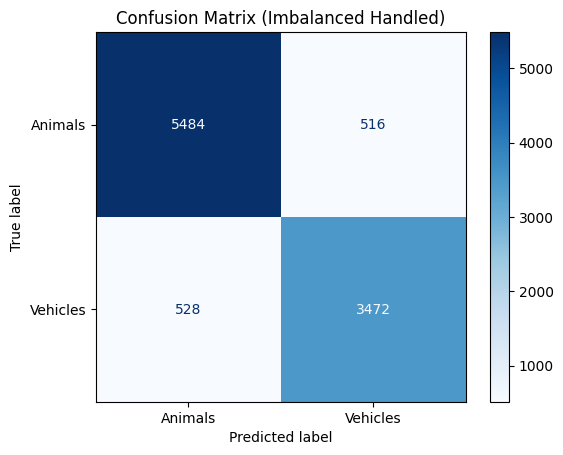

In [ ]:
#Grid Search for Polynomial kernel
poly_grid = {
    'C': [0.78,0.79,0.8,0.81],
    'coef0':[1],
    'degree': [3],
    'gamma': [0.0005,0.00032,0.0004],
}

start_time = time.time()
poly= GPU_SVC(kernel='poly',class_weight='balanced')
poly_grid_search = GPU_GridSearchCV(poly, poly_grid, cv=5, scoring='accuracy', verbose=3,return_train_score=True)
poly_grid_search.fit(x_train_scaled, y_train)

end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")

best_model = poly_grid_search.best_estimator_
print(f"Best params: {poly_grid_search.best_params_}")

y_pred = best_model.predict(x_test_scaled)
if hasattr(y_pred, 'to_numpy'): y_pred = y_pred.to_numpy()

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Animals', 'Vehicles']))
y_pred_train= best_model.predict(x_train_scaled)
print(accuracy_score(y_train, y_pred_train))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Animals', 'Vehicles'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Imbalanced Handled)")
plt.show()

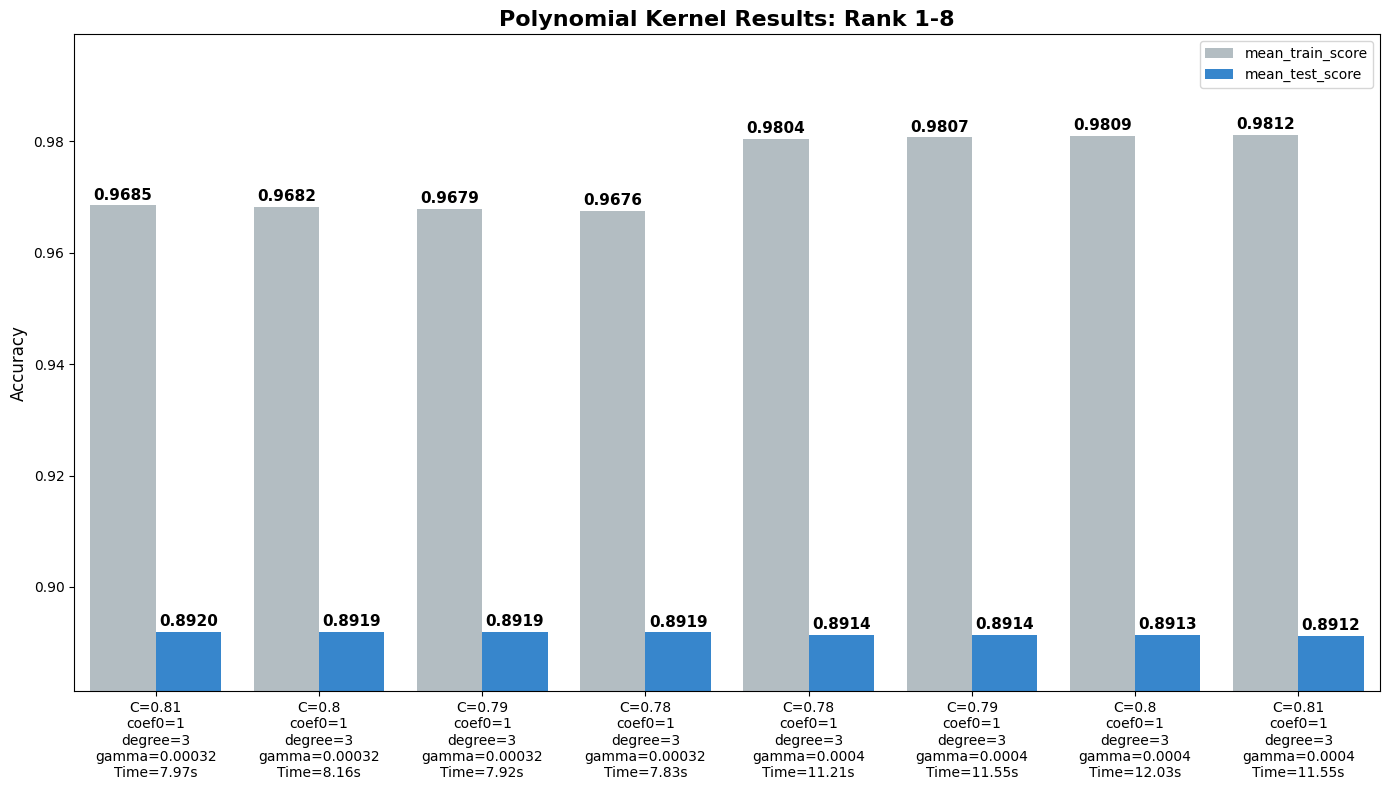

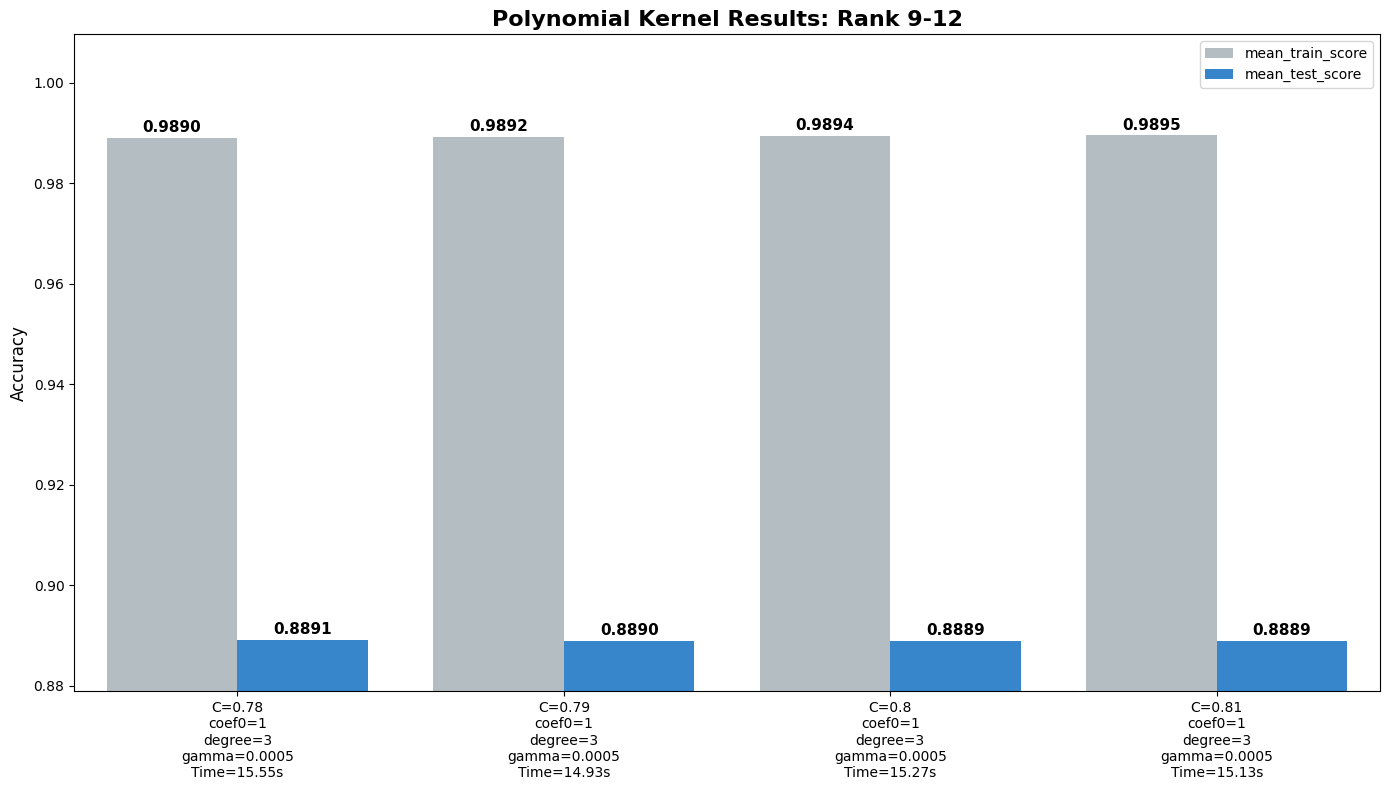

In [ ]:
plot_grid_search_results(poly_grid_search, title_prefix="Polynomial Kernel Results")

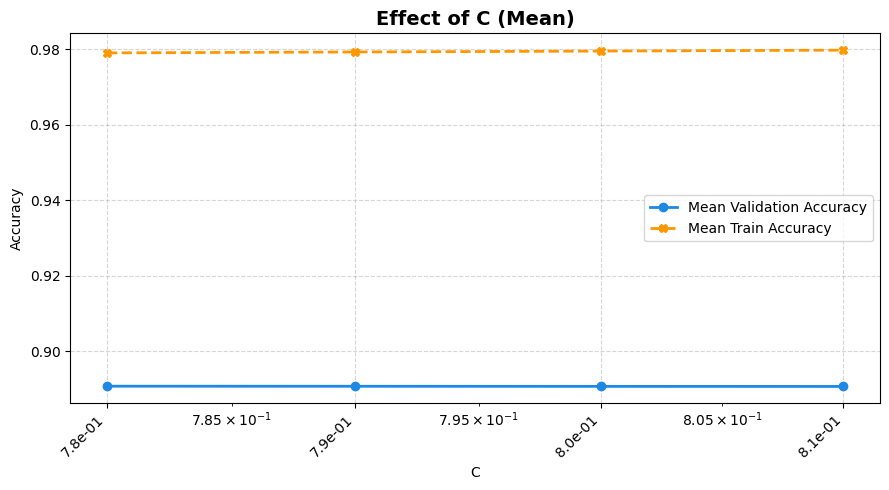

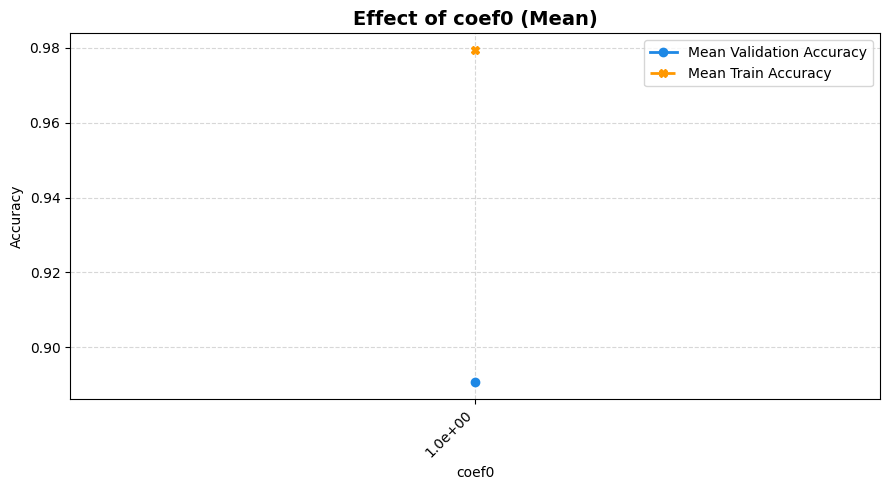

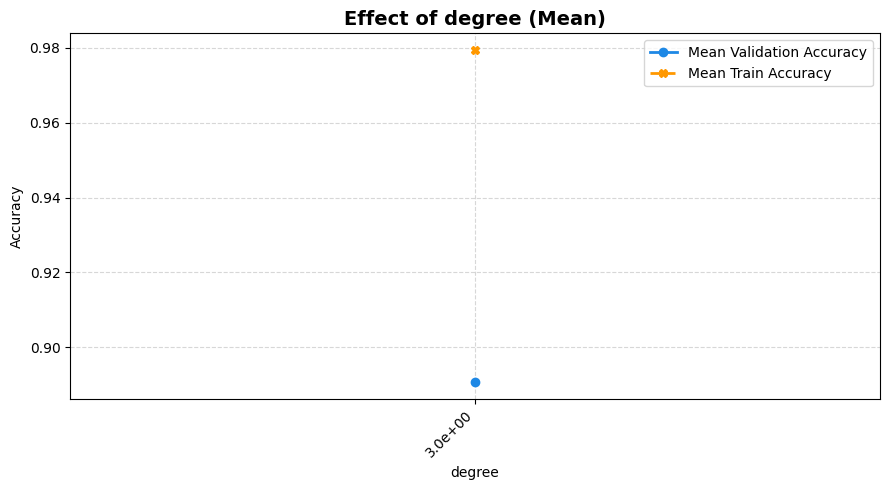

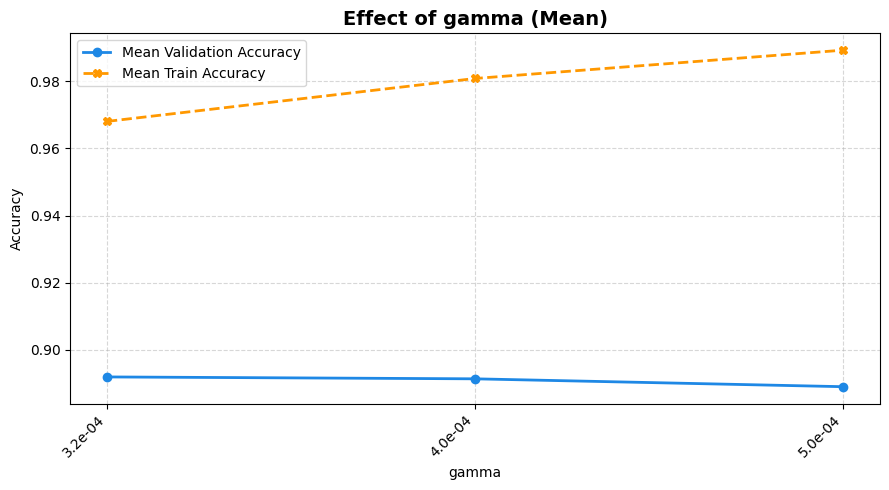

In [ ]:
plot_parameter_impact_mean(poly_grid_search)

In [ ]:
#RBF KERNEL grid search
rbf_grid={'C': [3.97,3.98,3.99,4,4.01,4.02,4.03],
    'gamma': [0.0006,'scale']}

print(f"Starting Grid Search (GPU)...")
start_time = time.time()
RBF= GPU_SVC(kernel='rbf',class_weight='balanced')
rbf_grid_search = GPU_GridSearchCV(RBF, rbf_grid, cv=5, scoring='accuracy', verbose=2,return_train_score=True)
rbf_grid_search.fit(x_train_scaled, y_train)

end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")

best_model = rbf_grid_search.best_estimator_
print(f"Best parameters: {rbf_grid_search.best_params_}")

y_pred = best_model.predict(x_test_scaled)
if hasattr(y_pred, 'to_numpy'): y_pred = y_pred.to_numpy()

print("\n--- Results (Full Data + Class Weight) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Animals', 'Vehicles']))
y_pred_train= best_model.predict(x_train_scaled)
print(accuracy_score(y_train, y_pred_train))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Animals', 'Vehicles'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Imbalanced Handled)")
plt.show()

In [ ]:
plot_grid_search_results(rbf_grid_search, title_prefix="RBF Kernel Results")

In [ ]:
plot_parameter_impact_mean(rbf_grid_search)

Manual Grid Search for Linear Kernel
Testing C values: [9e-06, 1e-05, 1.1e-05, 1.2e-05, 1.3e-05, 1.4e-05, 1.5e-05, 1.6e-05, 1.7e-05]
[2025-12-20 19:59:38.899] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
--> C=9e-06 | Test Acc: 0.8089 | Train Acc: 0.8114 | Time: 1.14s
[2025-12-20 19:59:51.974] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
--> C=1e-05 | Test Acc: 0.8094 | Train Acc: 0.8119 | Time: 1.06s
[2025-12-20 19:59:59.320] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
--> C=1.1e-05 | Test Acc: 0.8100 | Train Acc: 0.8121 | Time: 0.85s
--> C=1.2e-05 | Test Acc: 0.8102 | Train Acc: 0.8127 | Time: 0.77s
[2025-12-20 20:00:12.155] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
--> C=1.3e-05 | Test Acc: 0.8097 | Train Acc: 0.8126 | Time: 1.03s
[2025-12-20 20:00:13.387] [CUML] [wa

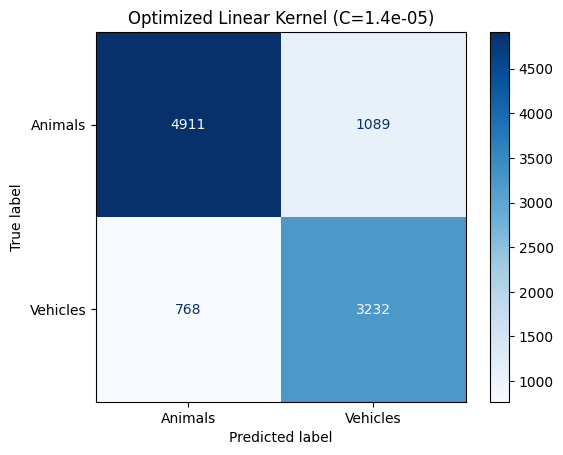

In [35]:
import numpy as np
import pandas as pd
import time
from cuml.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

param_grid = [9e-06, 1e-05, 1.1e-05, 1.2e-05, 1.3e-05, 1.4e-05, 1.5e-05, 1.6e-05, 1.7e-05]

print(f"Manual Grid Search for Linear Kernel")
print(f"Testing C values: {param_grid}")

best_score = -1
best_C = None

cv_results_data = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
start_time_total = time.time()


for C in param_grid:
    fold_test_scores = []
    fold_train_scores = []
    fold_times = []        #

    # 5-Fold CV
    for train_index, val_index in skf.split(x_train_scaled, y_train):
        X_tr, X_val = x_train_scaled[train_index], x_train_scaled[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]


        model = LinearSVC(
            C=C,
            class_weight='balanced',
            max_iter=5000,
            verbose=False
        )

        # Fit & Time Measurement
        t0 = time.time()
        model.fit(X_tr, y_tr)
        t1 = time.time()
        fold_times.append(t1 - t0)

        #VALIDATION SCORE
        preds = model.predict(X_val)
        if hasattr(preds, 'to_numpy'): preds = preds.to_numpy()
        elif hasattr(preds, 'get'): preds = preds.get()
        score = accuracy_score(y_val, preds)
        fold_test_scores.append(score)

        #TRAIN SCORE
        preds_train = model.predict(X_tr)
        if hasattr(preds_train, 'to_numpy'): preds_train = preds_train.to_numpy()
        elif hasattr(preds_train, 'get'): preds_train = preds_train.get()
        train_score = accuracy_score(y_tr, preds_train)
        fold_train_scores.append(train_score)

    #Mean Scores
    mean_test_acc = np.mean(fold_test_scores)
    mean_train_acc = np.mean(fold_train_scores)
    mean_time = np.mean(fold_times)


    cv_results_data.append({
        'params': C,
        'mean_test_score': mean_test_acc,
        'mean_train_score': mean_train_acc,
        'mean_fit_time': mean_time
    })

    print(f"--> C={C:<5} | Test Acc: {mean_test_acc:.4f} | Train Acc: {mean_train_acc:.4f} | Time: {mean_time:.2f}s")

    #Find best model
    if mean_test_acc > best_score:
        best_score = mean_test_acc
        best_C = C

end_time_total = time.time()
print(f"\n⏱️ Total Grid Search time: {end_time_total - start_time_total:.2f} seconds")
print(f"✅ Best C: {best_C} with Accuracy: {best_score:.4f}")

linear_results_df = pd.DataFrame(cv_results_data)

final_linear = LinearSVC(
    C=best_C,
    class_weight='balanced',
    max_iter=10000,
    verbose=False
)

final_linear.fit(x_train_scaled, y_train)

# Test Set Prediction
y_pred_final = final_linear.predict(x_test_scaled)
if hasattr(y_pred_final, 'to_numpy'): y_pred_final = y_pred_final.to_numpy()
elif hasattr(y_pred_final, 'get'): y_pred_final = y_pred_final.get()

print("Linear Optimized")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(classification_report(y_test, y_pred_final, target_names=['Animals', 'Vehicles']))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Animals', 'Vehicles'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Optimized Linear Kernel (C={best_C})")
plt.show()

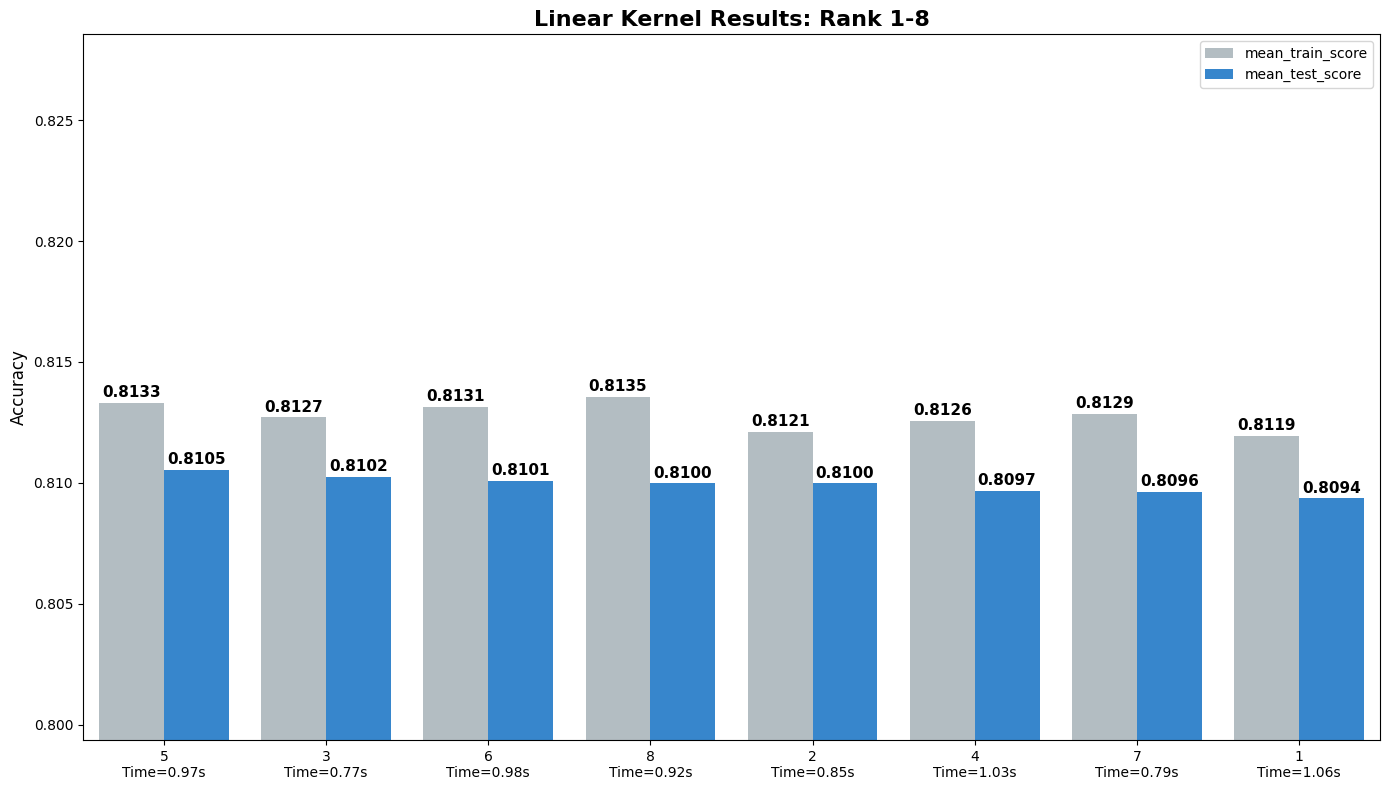

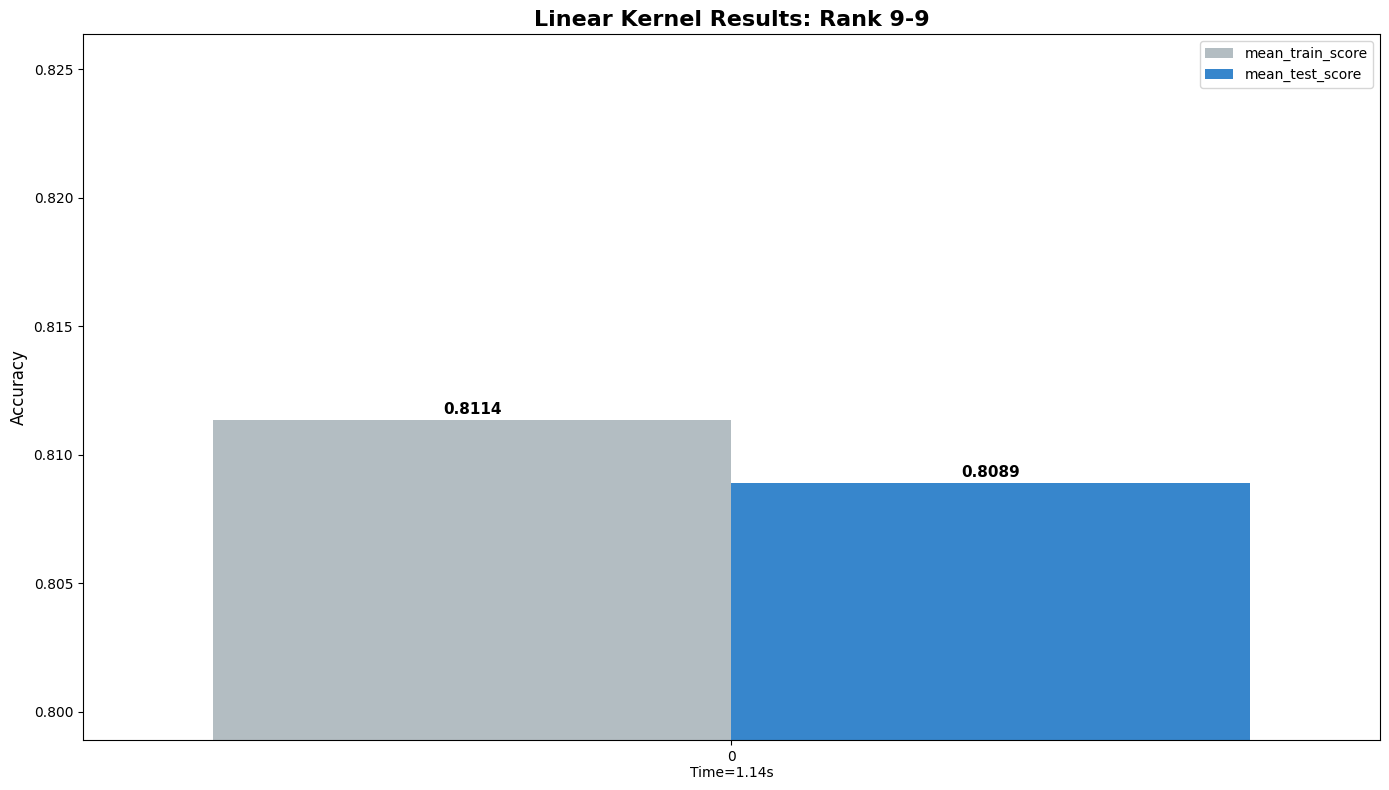

In [36]:
plot_grid_search_results(linear_results_df, title_prefix="Linear Kernel Results")

In [41]:
def plot_parameter_impact_simple(df):

    param_col = 'params'
    param_name = 'C'

    plot_df = df.sort_values(param_col)

    x = plot_df[param_col].values
    val = plot_df['mean_test_score'].values
    train = plot_df['mean_train_score'].values

    plt.figure(figsize=(9, 5))

    plt.plot(x, val, marker='o', linewidth=2,
             label='Validation Accuracy', color='#1e88e5')

    plt.plot(x, train, marker='X', linestyle='--', linewidth=2,
             label='Train Accuracy', color='#ff9800')

    plt.title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.xscale('log')
    plt.xticks(x, [f"{v:.1e}" for v in x], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

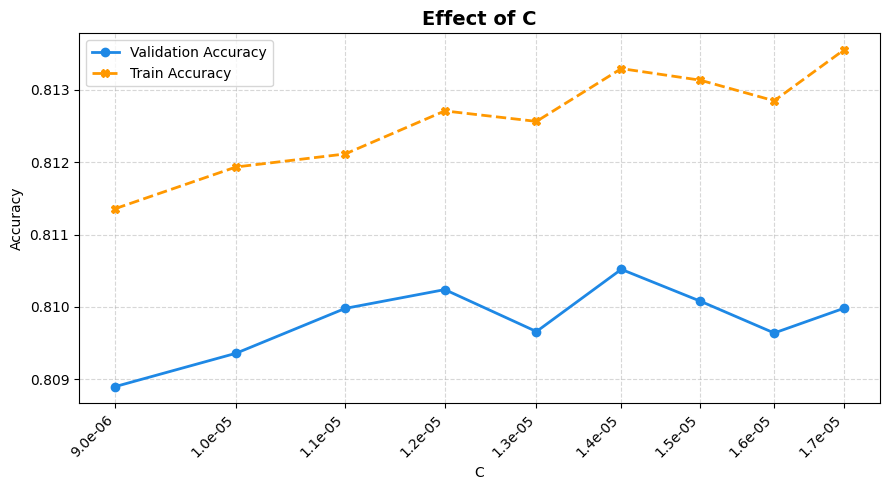

In [42]:
plot_parameter_impact_simple(linear_results_df)

In [ ]:
#Best Models training
models_svm = {
    'RBF Kernel': GPU_SVC(kernel='rbf', class_weight='balanced', C=4.1),
    'Polynomial Kernel': GPU_SVC(kernel='poly', class_weight='balanced', C=0.81, gamma='scale', degree=3, coef0=1),
    'Linear Kernel': LinearSVC(C=1.4e-5, class_weight='balanced', max_iter=5000, verbose=False)
}

time_dict_svm = {}
trained_models = {}
predictions_svm = {}

for name, model in models_svm.items():
    print(f"Training {name}...")

    # Training & Timing
    start_time = time.time()
    model.fit(x_train_scaled, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    time_dict_svm[name] = training_time

    trained_models[name] = model

    print(f"Predicting with {name}...")
    y_pred = model.predict(x_test_scaled)

    predictions_svm[name] = y_pred

    print(f"Training time: {training_time:.4f}s | Predictions saved.\n")


Training RBF Kernel...
Training time for RBF Kernel: 12.8437 seconds

Training Polynomial Kernel...
Training time for Polynomial Kernel: 17.3410 seconds

Training Linear Kernel...
Training time for Linear Kernel: 1.1825 seconds

Final SVM Training Times: {'RBF Kernel': 12.843713998794556, 'Polynomial Kernel': 17.34103226661682, 'Linear Kernel': 1.1825230121612549}


In [ ]:
# Function for Visualizing Correct vs. Incorrect Predictions
def visualize_model_predictions(y_pred, y_true, x_data, scaler, model_name="Model"):

    def get_label_name(val):
        return "Vehicle" if val == 1 else "Animal"

    scaler_mean = scaler.mean_
    scaler_std = scaler.scale_

    def prepare_image(flat_img, mean, std):
        # Inverse Standardization & Reshape
        img = flat_img * std + mean
        img = img.reshape(32, 32, 3)
        img = img / 255.0  # Normalization  [0, 1]
        img = np.clip(img, 0, 1)
        return img


    # y_pred
    if hasattr(y_pred, 'to_numpy'): y_pred_np = y_pred.to_numpy()
    elif hasattr(y_pred, 'get'): y_pred_np = y_pred.get()
    else: y_pred_np = y_pred

    # y_true
    if hasattr(y_true, 'to_numpy'): y_true_np = y_true.to_numpy()
    elif hasattr(y_true, 'values'): y_true_np = y_true.values
    else: y_true_np = y_true


    correct_indices = np.where(y_pred_np == y_true_np)[0]
    incorrect_indices = np.where(y_pred_np != y_true_np)[0]

    print(f"\n--- {model_name} Results ---")
    print(f"✅ Total Correct: {len(correct_indices)}")
    print(f"❌ Total Incorrect: {len(incorrect_indices)}")


    plt.figure(figsize=(14, 6))
    plt.suptitle(f"Predictions Visualization: {model_name}", fontsize=16)


    num_samples = min(5, len(correct_indices))
    random_correct = np.random.choice(correct_indices, num_samples, replace=False)

    for i, idx in enumerate(random_correct):
        ax = plt.subplot(2, 5, i + 1)


        img_data = x_data[idx].get() if hasattr(x_data, 'get') else x_data[idx]

        img_display = prepare_image(img_data, scaler_mean, scaler_std)
        ax.imshow(img_display)

        true_lab = get_label_name(y_true_np[idx])
        pred_lab = get_label_name(y_pred_np[idx])

        ax.set_title(f"True: {true_lab}\nPred: {pred_lab}", color="green", fontsize=10, fontweight='bold')
        ax.axis('off')
        if i == 2: ax.text(0.5, 1.15, "CORRECT EXAMPLES", transform=ax.transAxes, ha="center", fontsize=12, color="green")


    num_samples_err = min(5, len(incorrect_indices))
    if num_samples_err > 0:
        random_incorrect = np.random.choice(incorrect_indices, num_samples_err, replace=False)

        for i, idx in enumerate(random_incorrect):
            ax = plt.subplot(2, 5, i + 6)

            img_data = x_data[idx].get() if hasattr(x_data, 'get') else x_data[idx]

            img_display = prepare_image(img_data, scaler_mean, scaler_std)
            ax.imshow(img_display)

            true_lab = get_label_name(y_true_np[idx])
            pred_lab = get_label_name(y_pred_np[idx])

            ax.set_title(f"True: {true_lab}\nPred: {pred_lab}", color="red", fontsize=10, fontweight='bold')
            ax.axis('off')
            if i == 2: ax.text(0.5, 1.15, "INCORRECT EXAMPLES", transform=ax.transAxes, ha="center", fontsize=12, color="red")

    plt.tight_layout()
    plt.show()

In [4]:
for name, y_pred in predictions_svm.items():

    visualize_model_predictions(
        y_pred=y_pred,
        y_true=y_test,
        x_data=x_test_scaled,
        scaler=scaler,
        model_name=name
    )

In [ ]:
#RBF number of support vectors
print("RBF SVs:", trained_models['RBF Kernel'].n_support_)

#Polynomial number of support vectors
print("Poly SVs:", trained_models['Polynomial Kernel'].n_support_)